In [15]:
import re 

data = """
park 800905-1049118
kim 700905-1059119
"""

In [35]:
result = []
for line in data.split("\n"): 
    #result.append(line)
    word_result=[]
    
    for word in line.split(" "): 
        word_result.append(word)
        if len(word) == 14 and word[:6].isdigit() and word[7:].isdigit():
            word = word[:8]+"******"
            print("--->", word)
    
    #print(word_result)
    print(word)
    
#print(result)


800905-1******
700905-1******



In [37]:
import re 

data = """
park 800905-1049118
kim  700905-1059119
"""

pat = re.compile("(\d{6})[-]\d{7}")
print(pat.sub("\g<1>-*******", data))


park 800905-*******
kim  700905-*******



<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\plane\AppData\Local\Temp\ipykernel_15740\1187014391.py:8: SyntaxWarning: invalid escape sequence '\d'
  pat = re.compile("(\d{6})[-]\d{7}")
C:\Users\plane\AppData\Local\Temp\ipykernel_15740\1187014391.py:9: SyntaxWarning: invalid escape sequence '\g'
  print(pat.sub("\g<1>-*******", data))


In [41]:
import pandas as pd
import numpy as np
df = pd.DataFrame({'A': [1, 2, np.nan, 4, 5],
'B': [6, 7, 8, np.nan, 10],
'C': [11, 12, 13, np.nan, np.nan]})
df

,A,B,C
0,1.0,6.0,11.0
1,2.0,7.0,12.0
2,NaN,8.0,13.0
3,4.0,NaN,NaN
4,5.0,10.0,NaN


In [43]:
pd.isna(df)

,A,B,C
0,False,False,False
1,False,False,False
2,True,False,False
3,False,True,True
4,False,False,True


In [45]:
pd.isna(df).sum( )

A    1
B    1
C    2
dtype: int64

In [47]:
df_drop_nan = df.dropna( )
df_drop_nan

,A,B,C
0,1.0,6.0,11.0
1,2.0,7.0,12.0


In [3]:
df = pd.DataFrame({'A': [1, 2, np.nan, 4, 5],
'B': [6, 7, 8, np.nan, 10],
'C': [11, 12, 13, np.nan, np.nan]})
df

NameError: name 'pd' is not defined

In [51]:
df_missing = df['A'].fillna('missing')
df_missing

0        1.0
1        2.0
2    missing
3        4.0
4        5.0
Name: A, dtype: object

In [61]:
df_mean = df.fillna(df.mean( ))
print(df, '\n')
print(df_mean)

     A     B     C
0  1.0   6.0  11.0
1  2.0   7.0  12.0
2  NaN   8.0  13.0
3  4.0   NaN   NaN
4  5.0  10.0   NaN 

     A      B     C
0  1.0   6.00  11.0
1  2.0   7.00  12.0
2  3.0   8.00  13.0
3  4.0   7.75  12.0
4  5.0  10.00  12.0


In [67]:
print(df, '\n')
#결측치바로위의값으로대체하기
df_ffill = df.fillna(method='ffill')
print(df_ffill, '\n')
#결측치바로아래의값으로대체하기
df_bfill = df.fillna(method='bfill')
print(df_bfill)

     A     B     C
0  1.0   6.0  11.0
1  2.0   7.0  12.0
2  NaN   8.0  13.0
3  4.0   NaN   NaN
4  5.0  10.0   NaN 

     A     B     C
0  1.0   6.0  11.0
1  2.0   7.0  12.0
2  2.0   8.0  13.0
3  4.0   8.0  13.0
4  5.0  10.0  13.0 

     A     B     C
0  1.0   6.0  11.0
1  2.0   7.0  12.0
2  4.0   8.0  13.0
3  4.0  10.0   NaN
4  5.0  10.0   NaN


C:\Users\plane\AppData\Local\Temp\ipykernel_15740\3541494602.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill = df.fillna(method='ffill')
C:\Users\plane\AppData\Local\Temp\ipykernel_15740\3541494602.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method='bfill')


In [183]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime, date, time
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'gulim'

In [185]:
path = 'C:/ws/HD_Rotem2_pycode/data_study_01/08장/대전태평(암반)/'
file_list = os.listdir(path)
file_list_py = [file for file in file_list if file.endswith('.xlsx')]
file_list_py

['대전태평(암반)_2009_hr.xlsx',
 '대전태평(암반)_2010_hr.xlsx',
 '대전태평(암반)_2011_hr.xlsx',
 '대전태평(암반)_2012_hr.xlsx',
 '대전태평(암반)_2013_hr.xlsx',
 '대전태평(암반)_2014_hr.xlsx',
 '대전태평(암반)_2015_hr.xlsx',
 '대전태평(암반)_2016_hr.xlsx']

In [187]:
df = pd.DataFrame()
for i in file_list_py: 
    data = pd.read_excel(path + i)
    df = pd.concat([df, data])
df

,관측소,구분,날짜,시간,수온(℃),수위(el.m),EC(㎲/㎝)
0,대전태평,(암반),20090101,0,16.1,44.47,749
1,대전태평,(암반),20090101,1,16.1,44.47,749
2,대전태평,(암반),20090101,2,16.1,44.47,749
3,대전태평,(암반),20090101,3,16.1,44.47,749
4,대전태평,(암반),20090101,4,16.1,44.47,749
...,...,...,...,...,...,...,...
8761,대전태평,(암반),20161231,19,16.2,44.49,725
8762,대전태평,(암반),20161231,20,16.2,44.49,725
8763,대전태평,(암반),20161231,21,16.2,44.49,725
8764,대전태평,(암반),20161231,22,16.2,44.49,725


In [188]:
df = df.reset_index(drop=True)
df

,관측소,구분,날짜,시간,수온(℃),수위(el.m),EC(㎲/㎝)
0,대전태평,(암반),20090101,0,16.1,44.47,749
1,대전태평,(암반),20090101,1,16.1,44.47,749
2,대전태평,(암반),20090101,2,16.1,44.47,749
3,대전태평,(암반),20090101,3,16.1,44.47,749
4,대전태평,(암반),20090101,4,16.1,44.47,749
...,...,...,...,...,...,...,...
69543,대전태평,(암반),20161231,19,16.2,44.49,725
69544,대전태평,(암반),20161231,20,16.2,44.49,725
69545,대전태평,(암반),20161231,21,16.2,44.49,725
69546,대전태평,(암반),20161231,22,16.2,44.49,725


In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69548 entries, 0 to 69547
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   관측소       69548 non-null  object 
 1   구분        69548 non-null  object 
 2   날짜        69548 non-null  int64  
 3   시간        69548 non-null  int64  
 4   수온(℃)     69548 non-null  float64
 5   수위(el.m)  69548 non-null  float64
 6   EC(㎲/㎝)   69548 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 3.7+ MB


In [193]:
df['Date'] = pd.to_datetime(df['날짜'],format='%Y%m%d') + pd.to_timedelta(df['시간'].astype(int),unit='h')
                    
df.set_index(df['Date'], inplace=True)
df.head(3)

,관측소,구분,날짜,시간,수온(℃),수위(el.m),EC(㎲/㎝),Date
Date,,,,,,,,
2009-01-01 00:00:00,대전태평,(암반),20090101,0,16.1,44.47,749,2009-01-01 00:00:00
2009-01-01 01:00:00,대전태평,(암반),20090101,1,16.1,44.47,749,2009-01-01 01:00:00
2009-01-01 02:00:00,대전태평,(암반),20090101,2,16.1,44.47,749,2009-01-01 02:00:00


In [195]:
df1 = df[['수온(℃)', '수위(el.m)','EC(㎲/㎝)']]
df1.columns = ['temp', 'level', 'EC']
df1.head(3)

,temp,level,EC
Date,,,
2009-01-01 00:00:00,16.1,44.47,749
2009-01-01 01:00:00,16.1,44.47,749
2009-01-01 02:00:00,16.1,44.47,749


In [197]:
df1.isnull( ).sum( )

temp     0
level    0
EC       0
dtype: int64

In [199]:
df1.to_csv('./대전지하수.csv', encoding='cp949')

In [243]:
df = pd.read_csv('./대전지하수.csv', index_col = 'Date', parse_dates = True, encoding = 'cp949')
df.describe()

,temp,level,EC
count,69548.000000,69548.000000,69548.000000
mean,16.262491,44.295353,727.024027
std,0.089778,2.539464,51.544590
min,15.800000,11.530000,13.000000
25%,16.200000,44.370000,722.000000
50%,16.300000,44.460000,730.000000
75%,16.300000,44.550000,742.000000
max,16.500000,45.900000,778.000000


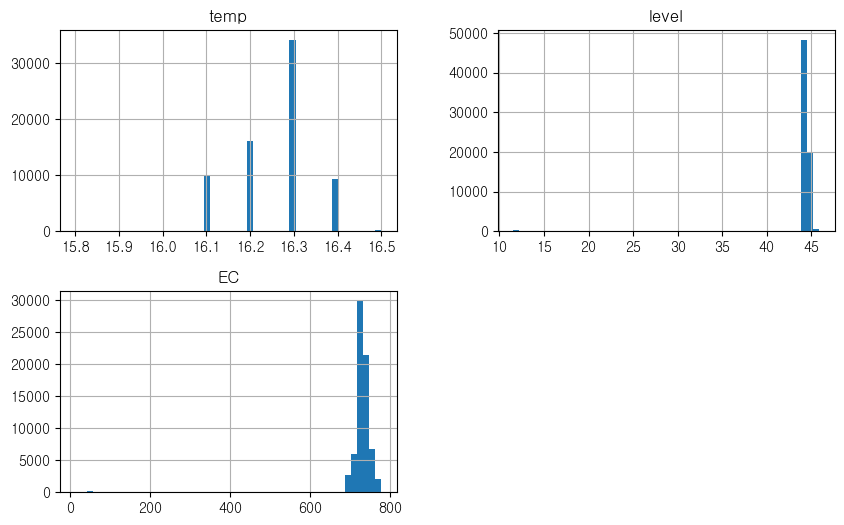

In [203]:
df.hist(bins=50, figsize = (10,6))
plt.show()

<Axes: >

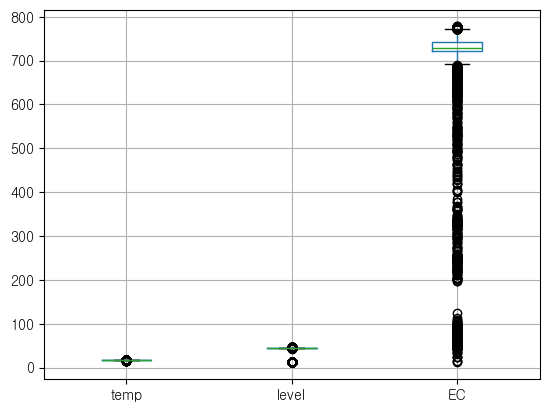

In [205]:
df.boxplot()

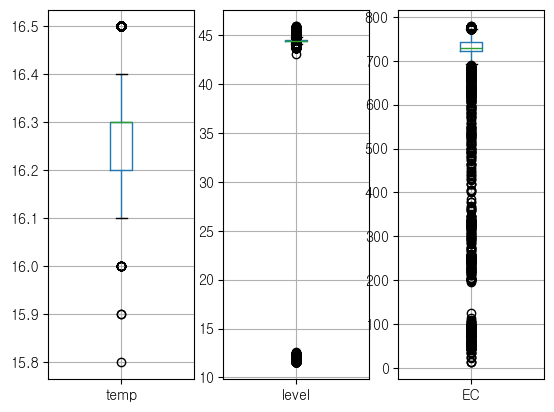

In [207]:
plt.subplot(1, 3, 1)
df.boxplot(column='temp', return_type='both')
plt.subplot(1, 3, 2)
df.boxplot(column='level', return_type='both')
plt.subplot(1, 3, 3)
df.boxplot(column='EC', return_type='both')
plt.show( )

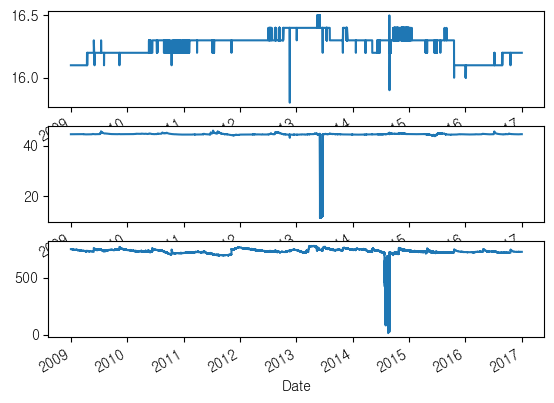

In [209]:
plt.subplot(3,1,1)
df['temp'].plot()
plt.subplot(3,1,2)
df['level'].plot()
plt.subplot(3,1,3)
df['EC'].plot()
plt.show()

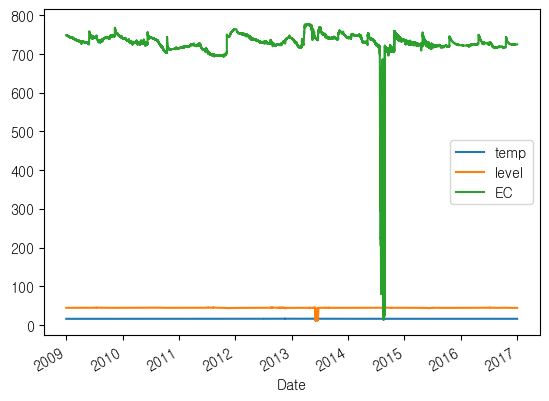

In [211]:
df.plot()
plt.show()

In [245]:
q3_level = df['level'].quantile(q = 0.75)
q1_level = df['level'].quantile(q = 0.25)
iqr_level = q3_level - q1_level
print(iqr_level)

0.17999999999999972


In [247]:
upper_level = q3_level + 1.5 * iqr_level
lower_level = q1_level -1.5 * iqr_level
print(upper_level, '/', lower_level)
print((df['level'] > upper_level).sum( ))
print((df['level'] < lower_level).sum( ))

44.81999999999999 / 44.099999999999994
4492
1273


<Axes: xlabel='Date'>

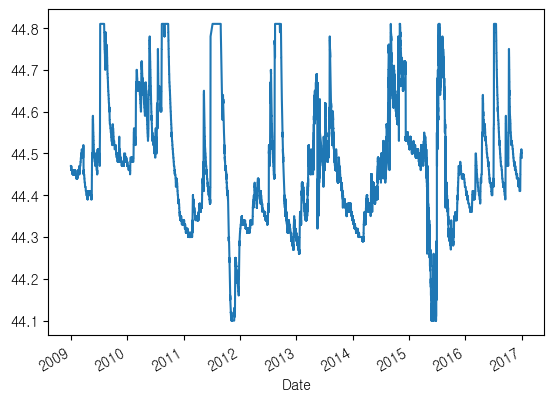

In [249]:
df_iqr_level = df[(df['level'] < upper_level) & (df['level'] > lower_level)]
df_iqr_level['level'].plot()

In [251]:
#사분위수와IQR 구하기
q3_temp = df['temp'].quantile(q=0.75)
q1_temp = df['temp'].quantile(q=0.25)
iqr_temp = q3_temp-q1_temp
print('IQR:', iqr_temp)
#지하수온상한값, 하한값, 이상치개수구하기
upper_temp = q3_temp + iqr_temp * 1.5
lower_temp = q1_temp -iqr_temp * 1.5
print(upper_temp, '/', lower_temp)
print((df['temp'] > upper_temp).sum( ))
print((df['temp'] < lower_temp).sum( ))

IQR: 0.10000000000000142
16.450000000000003 / 16.049999999999997
227
15


In [253]:
#코드 8-29
#사분위수와 IQR 구하기
q3_ec = df['EC'].quantile(q=0.75)
q1_ec = df['EC'].quantile(q=0.25)
iqr_ec = q3_ec - q1_ec
print('IQR:', iqr_ec)
#지하수온 상한값, 하한값, 이상치 개수 구하기
upper_ec = q3_ec + iqr_ec * 1.5
lower_ec = q1_ec - iqr_ec * 1.5
print(upper_ec, '/', lower_ec)
print((df['EC'] > upper_ec).sum())
print((df['EC'] < lower_ec).sum())

IQR: 20.0
772.0 / 692.0
831
788


In [255]:
#코드 8-30
df_iqr = df[(df['temp'] < upper_temp) & (df['temp'] > lower_temp) &\
            (df['level'] < upper_level) & (df['level'] > lower_level) &\
             (df['EC'] < upper_ec) & (df['EC'] > lower_ec)]

In [257]:
#코드 8-31
df_iqr.describe()

,temp,level,EC
count,61814.000000,61814.000000,61814.000000
mean,16.256793,44.459701,731.698612
std,0.089692,0.128256,13.882905
min,16.100000,44.100000,693.000000
25%,16.200000,44.370000,722.000000
50%,16.300000,44.450000,730.000000
75%,16.300000,44.520000,742.000000
max,16.400000,44.810000,771.000000


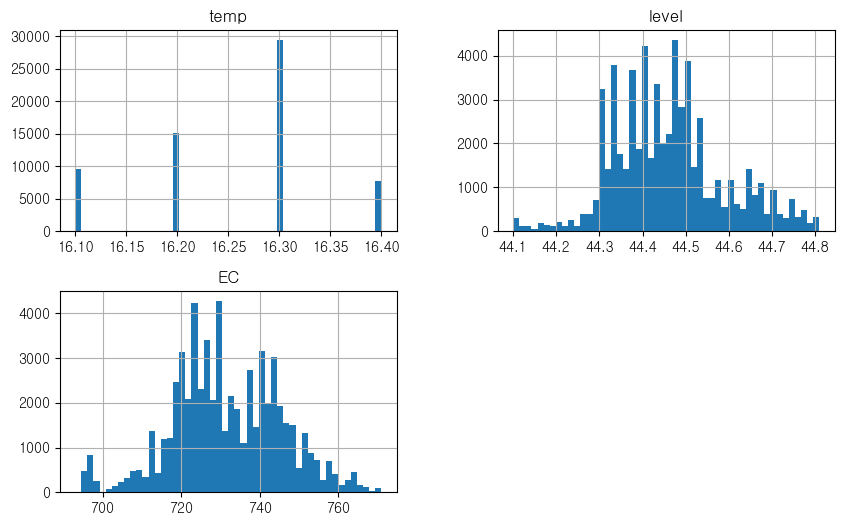

In [259]:
df_iqr.hist(bins=50, figsize=(10,6))
plt.show( )

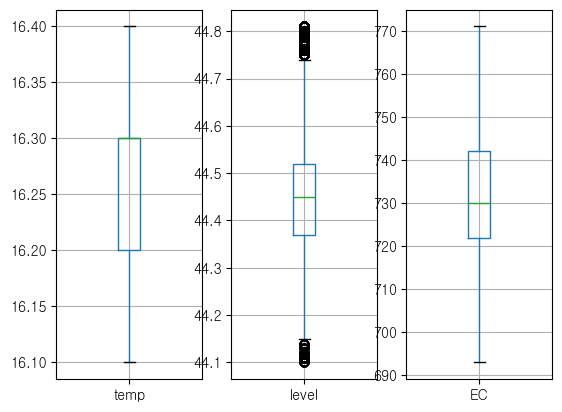

In [229]:
plt.subplot(1, 3, 1)
df_iqr.boxplot(column='temp', return_type='both')
plt.subplot(1, 3, 2)
df_iqr.boxplot(column='level', return_type='both')
plt.subplot(1, 3, 3)
df_iqr.boxplot(column='EC', return_type='both')
plt.show()

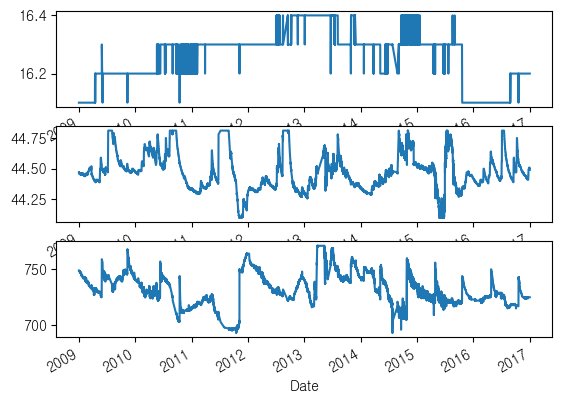

In [230]:
plt.subplot(3, 1, 1)
df_iqr['temp'].plot( )
plt.subplot(3, 1, 2)
df_iqr['level'].plot( )
plt.subplot(3, 1, 3)
df_iqr['EC'].plot( )
plt.show( )

In [233]:
df_iqr.to_csv('대전지하수_정제.csv', encoding='cp949')

In [261]:
#코드 8-37
df = df[['level', 'EC']]
df.describe()

,level,EC
count,69548.000000,69548.000000
mean,44.295353,727.024027
std,2.539464,51.544590
min,11.530000,13.000000
25%,44.370000,722.000000
50%,44.460000,730.000000
75%,44.550000,742.000000
max,45.900000,778.000000


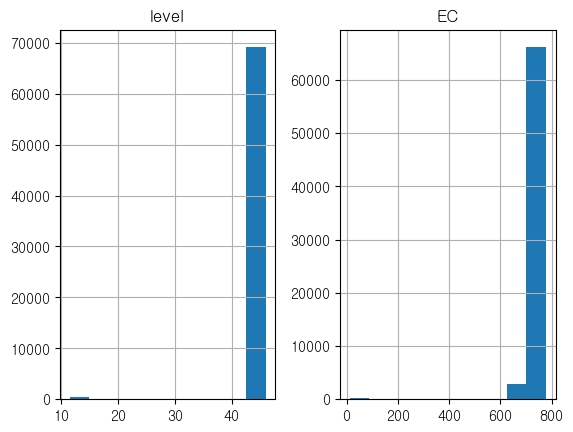

In [241]:
df.hist()
plt.show()